# Reproducing the Product Space: A Network Analysis of Global Trade Complexity
**Tommaso Accornero**
**Universidad Carlos III de Madrid, 2026**

---

### Abstract

This notebook reproduces and reinterprets the structural network analysis of the 
**Product Space** introduced by Hidalgo et al. (2007) in their landmark 
paper *"The Product Space Conditions the Development of Nations"* (Science, 317).

The Product Space is a network of 774 economic products, where two products are 
connected if they are systematically co-exported by the same countries — 
reflecting shared productive capabilities. The original paper argued that the 
structure of this network fundamentally shapes a country's ability to diversify 
its economy: countries can only move into products that are close to their 
existing capabilities.

Using Python and NetworkX, I analyse the network's structural properties — 
degree distribution, assortativity, community structure, centrality, and 
clustering — and test whether its key features can be explained by a random 
null model. The analysis confirms the core-periphery structure and heavy-tailed 
degree distribution described in the original paper, and provides new community-
level interpretations using the Louvain algorithm.

**Data source:** Coscia, M. & Hidalgo, C.A. — The Product Space (SITC classification).  
Available at: [icon.colorado.edu](https://icon.colorado.edu) via [michelecoscia.com](https://www.michelecoscia.com/?page_id=223)

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

In [22]:
# Load nodes and edges
nodes = pd.read_csv("data/PS_SITC_nodes", sep="\t", header=None)
edges = pd.read_csv("data/PS_SITC_edges", sep="\t", header=None)

# Build the graph
G = nx.from_pandas_edgelist(edges, source=0, target=3, edge_attr=6)

# Add product names as node attributes
node_names = dict(zip(nodes[0], nodes[6]))
nx.set_node_attributes(G, node_names, "name")

print("Data loaded and graph built successfully")
print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")

Data loaded and graph built successfully
Nodes: 774
Edges: 1779


---

## 1. Network Description

The Product Space is formally defined as a graph $G = (V, E)$ where nodes 
represent individual products and edges connect products that require similar 
productive capabilities. I begin by characterising its basic structural properties.

In [23]:
# Q1 - Network description
N = G.number_of_nodes()
L = G.number_of_edges()
max_edges = N * (N - 1) / 2
sparsity = 1 - (L / max_edges)

print(f"Number of nodes (products): {N}")
print(f"Number of edges (connections): {L}")
print(f"Maximum possible edges: {int(max_edges)}")
print(f"Sparsity: {sparsity:.4f}")

Number of nodes (products): 774
Number of edges (connections): 1779
Maximum possible edges: 299151
Sparsity: 0.9941


**Answer:**

The Product Space is a network of economic products, where **nodes** represent individual products (774 in total), while **edges** connect pairs of products that tend to be exported together by the same countries (1,779 connections). A link between two products means that they require a similar mode of production in order to be manufactured.

The network is extremely sparse, as we can see with a sparsity of **0.9941**. This means that 99.4% of all possible connections are absent. Economically, this makes sense. Most products do not share the same processes nor the same skills and tools that go into their manufacturing. In addition, countries rarely specialize in two completely unrelated products simultaneously.

---

## 2. Degree Distribution Analysis

I examine the degree sequence of the network — the number of connections each 
product has — and assess whether the average degree is a meaningful summary 
statistic given the distribution's shape.

In [24]:
# Q2 - Degree analysis
degrees = [d for n, d in G.degree()]

avg_degree = np.mean(degrees)
std_degree = np.std(degrees)

print(f"Average degree: {avg_degree:.4f}")
print(f"Standard deviation: {std_degree:.4f}")
print(f"Min degree: {min(degrees)}")
print(f"Max degree: {max(degrees)}")

Average degree: 4.5969
Standard deviation: 5.9910
Min degree: 1
Max degree: 43


**Answer:**

The average degree is **4.60** with a standard deviation of **5.99**. The minimum degree is 1 and the maximum is 43.

The fact that the SD is larger than the average is a red flag and a core feature of this dataset. Therefore, the average degree is **not a good descriptor** in this case. 

As aforementioned, the standard deviation is larger than the mean itself, signalling high dispersion. A small number of products are connected to many others while the majority have very few connections. This heterogeneity makes the average misleading.

This is like describing income inequality with a mean salary that no one actually earns. The degree distribution is likely heavy-tailed, which is what we try to verify in the next section.

---

## 3. Degree Distribution

I plot the degree distribution on both linear-linear and log-log scales to 
identify whether the network follows a heavy-tailed power-law distribution, 
as predicted by the hub-and-spoke structure of the original Product Space.

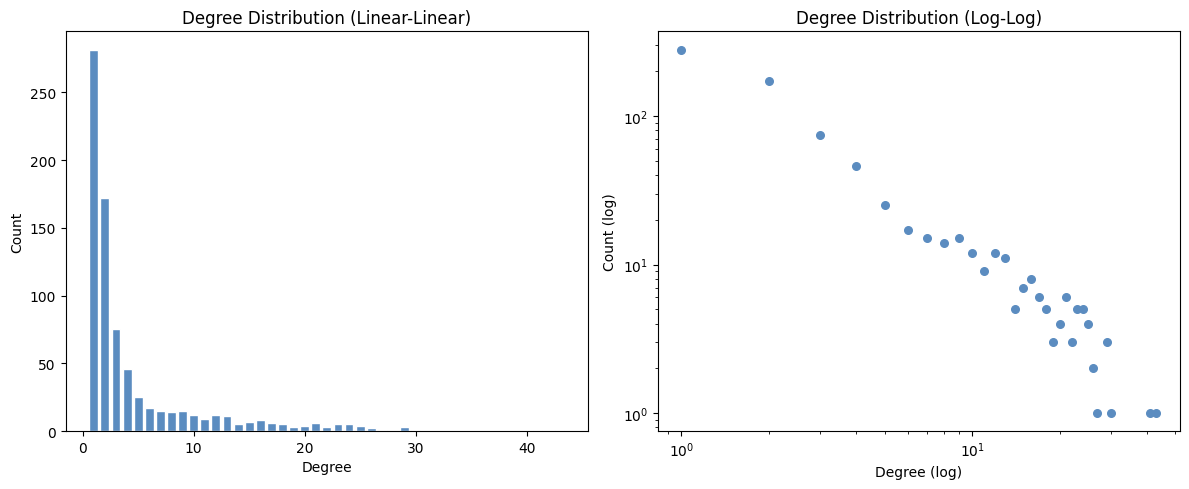

In [25]:
# Q3 - Degree distribution
degrees = [d for n, d in G.degree()]
degree_counts = np.bincount(degrees)
degree_values = np.arange(len(degree_counts))

# Remove zeros for log-log plot
mask = degree_counts > 0
x = degree_values[mask]
y = degree_counts[mask]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Linear-linear
axes[0].bar(x, y, color="#5b8cc0", edgecolor="white")
axes[0].set_xlabel("Degree")
axes[0].set_ylabel("Count")
axes[0].set_title("Degree Distribution (Linear-Linear)")

# Log-log
axes[1].scatter(x, y, color="#5b8cc0", s=30)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("Degree (log)")
axes[1].set_ylabel("Count (log)")
axes[1].set_title("Degree Distribution (Log-Log)")

plt.tight_layout()
plt.savefig("degree_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

**Answer:**

The linear-linear plot reveals a strongly right-skewed distribution. That tells us that the vast majority of products have very few connections, with a long tail of highly connected products. However, the scale makes it difficult to read the tail.

The log-log plot is better suited for this network. The roughly linear downward pattern on log-log axes is the signature of a **power-law distribution**, where a small number of hub products concentrate most connections while most products remain peripheral. This is consistent with the findings of Hidalgo et al. (2007), who used this dataset and showed that the Product Space is dominated by a dense core of interconnected products surrounded by a sparse periphery.

---

## 4. Degree Assortativity

Assortativity measures whether high-degree nodes tend to connect to other 
high-degree nodes. A positive value would confirm the rich-club effect 
described in the original paper — where core industrial products cluster together.

In [26]:
# Q4 - Degree assortativity
assortativity = nx.degree_assortativity_coefficient(G)
print(f"Degree assortativity: {assortativity:.4f}")

Degree assortativity: 0.4571


**Answer:**

The degree assortativity coefficient is **0.4571**, indicating moderate positive assortativity. This means that highly connected products tend to connect to other highly connected products, forming a dense core in the network. 

Economically, this reflects the well-documented core-periphery structure of the Product Space: sophisticated industrial products such as machinery, chemicals, and metals cluster together in a dense core, while peripheral products such as raw materials and agricultural goods remain isolated at the edges. Countries that 
successfully export core products can more easily diversify into other core products, while peripheral exporters face much larger capability gaps.

---

## 5. Community Structure

I apply the Louvain community detection algorithm to identify clusters of 
products that are more densely connected to each other than to the rest of the 
network. If the capability theory holds, these communities should correspond 
to recognisable industrial sectors.

In [27]:
# Q5 - Community detection using Louvain method
communities = nx.community.louvain_communities(G, seed=42)

# Assign community membership to each node
community_map = {}
for i, community in enumerate(communities):
    for node in community:
        community_map[node] = i

nx.set_node_attributes(G, community_map, "community")

# Print summary
print(f"Number of communities detected: {len(communities)}")
print(f"Modularity: {nx.community.modularity(G, communities):.4f}")
print()

# Print community sizes and top products
for i, community in enumerate(communities):
    names = [G.nodes[n]["name"] for n in community]
    print(f"Community {i+1} ({len(community)} products): {names[:3]}")

Number of communities detected: 35
Modularity: 0.7563

Community 1 (112 products): ['STRUCTURES& PARTS OF STRUC.;ALUMINIUM;PLATES,RODS', 'ACYCLIC ALCOHOLS & THEIR HALOGENATED,DERIVATIVES', 'WASTE AND SCRAP METAL OF IRON OR STEEL']
Community 2 (62 products): ['OPTICAL INSTRUMENTS AND APPARATUS', 'LENSES,PRISMS,MIRRORS,OTHER OPTICAL ELEMENTS', 'IMITATION JEWELLERY']
Community 3 (50 products): ['JERSEYS,PULL-OVERS,TWINSETS,CARDIGANS,KNITTED', 'DRESSES,SKIRTS,SUITS ETC,KNITTED OR CROCHETED', 'ESSENTIAL OILS,CONCRETES & ABSOLUTES:RESINOIDS']
Community 4 (6 products): ['SALTS OF METALLIC ACIDS; ETC.', 'QUARTZ,MICA,FELSPAR,FLUORSPAR,CRYOLITE & CHIOLITE', 'CHEMICAL ELEMENTS']
Community 5 (96 products): ['ART,COLLECTORS PIECES & ANTIQUES', 'CYCLIC.ALCOHOLS & THEIR HALOGENATED DERIVATIVES', 'PHENOLS & PHEN.-ALCO.& THEIR HALOGENAT.DERIVATIVES']
Community 6 (8 products): ['PUDDLED BARS AND PILINGS;INGOTS,BLOCKS,LUMPS ETC.', 'BLOOMS,BILLETS,SLABS & SHEET BARS OF IRON OR STEEL', 'COPPER AND COPPER A

**Answer:**

The Product Space is an **undirected** network. An edge between two products simply means they are co-exported by the same countries, with no apparent and inherent directionality. This makes the Louvain method applicable here.

The Louvain algorithm detected **35 communities** with a modularity of **0.7563**, indicating very strong community structure (values above 0.3 are generally considered significant). 

The detected communities are economically interpretable and map closely onto real industrial sectors:
- **Community 1** (112 products): raw metals, chemicals, and industrial materials
- **Community 2** (62 products): optical instruments and electronics
- **Community 3** (50 products): textiles and garments
- **Community 8** (52 products): Mediterranean agricultural products (olive oil, cork, livestock)
- **Community 9** (3 products): shipbuilding (warships, vessels)
- **Community 21** (125 products): the industrial core (machinery, pumps, electrical equipment)

This is consistent with the original findings of Hidalgo et al. (2007): products cluster together because they require similar productive capabilities, and countries that master one product in a cluster find it easier to diversify into others within the same community.

---

## 6. Centrality Analysis

I compute degree and betweenness centrality to identify the most important 
products in the network under two different definitions of importance: 
connectivity (how many products a node is linked to) and bridging capacity 
(how often a node lies on the shortest path between other products).

In [28]:
# Q6 - Degree and betweenness centrality
degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G)

# Sort by centrality score
top5_degree = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:5]
top5_betweenness = sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True)[:5]

# Print top 5 degree centrality
print("Top 5 nodes by DEGREE centrality:")
for node, score in top5_degree:
    print(f"  {G.nodes[node]['name']}: {score:.4f}")

print()

# Print top 5 betweenness centrality
print("Top 5 nodes by BETWEENNESS centrality:")
for node, score in top5_betweenness:
    print(f"  {G.nodes[node]['name']}: {score:.4f}")

Top 5 nodes by DEGREE centrality:
  TRANSMISSION SHAFTS,CRANKS,BEARING HOUSINGS ETC.: 0.0556
  OTHER PARTS & ACCESSORIES OF MOTOR VEHICLES: 0.0530
  PARTS OF THE PUMPS & LIQ.ELEVATORS OF 742-: 0.0388
  RAIL&TRAMWAY TRACK FIXTURES&FITTINGS,SIGNALL.EQUI.: 0.0375
  ELECTRIC INSULATING EQUIPMENT: 0.0375

Top 5 nodes by BETWEENNESS centrality:
  SLAG WOOL.ROCK WOOL AND SIMILAR MINERAL WOOLS: 0.2297
  ARTICLES OF IRON OR STEEL, N.E.S.: 0.1415
  FURNACE BURNERS FOR LIQUID FUEL AND PARTS: 0.1406
  LUBRICATING PETROL.OILS & OTHER HEAVY PETROL.OILS: 0.1286
  BAKERY PRODUCTS (E.G.,BREAD,BISCUITS,CAKES) ETC.: 0.1262


**Answer:**

The two centrality measures give us very interesting insights into the dataset. We obtain two completely different sets of products, which reveals the multidimensional nature of importance in this network.

**Top 5 by Degree Centrality** (most direct connections):
1. Transmission shafts, cranks, bearing housings (0.0556)
2. Other parts & accessories of motor vehicles (0.0530)
3. Parts of pumps & liquid elevators (0.0388)
4. Rail & tramway track fixtures & signalling equipment (0.0375)
5. Electric insulating equipment (0.0375)

**Top 5 by Betweenness Centrality** (most bridge-like):
1. Slag wool, rock wool and similar mineral wools (0.2297)
2. Articles of iron or steel, N.E.S. (0.1415)
3. Furnace burners for liquid fuel and parts (0.1406)
4. Lubricating petroleum oils & other heavy petroleum oils (0.1286)
5. Bakery products (0.1262)

The lists are entirely different between each other. Degree centrality identifies **industrial hub products**, these are sophisticated machinery components sitting at the dense core of the network, connected to many similar products. 

Betweenness centrality identifies **bridge products**, goods that connect otherwise distant parts of the network, linking different industrial communities together.

Here, motor vehicle parts dominate by connectivity while mineral wool and generic iron articles dominate by bridging capacity. This is likely because they are intermediate inputs used across many unrelated industries.

---

## 7. Configuration Model Test

To test whether the network's clustering structure reflects genuine economic 
mechanisms or is simply a byproduct of its degree sequence, I compare the 
empirical clustering coefficient against an ensemble of 200 random networks 
generated by the configuration model — which preserves the degree sequence 
but randomises all connections.

Empirical clustering coefficient: 0.4297
Null model mean: 0.0332
Null model std: 0.0028
Z-score: 142.61


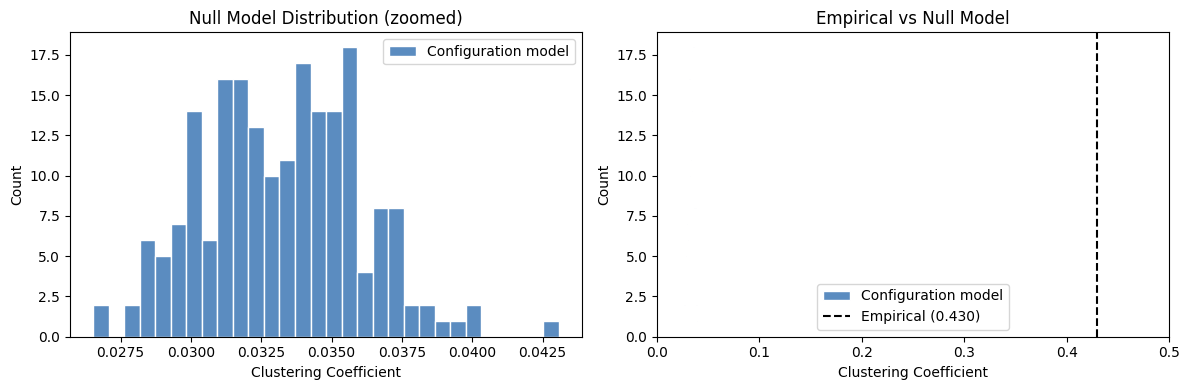

In [29]:
# Q7 - Configuration model test
n_networks = 200
degree_sequence = [d for n, d in G.degree()]

ensemble_conf = [
    nx.configuration_model(degree_sequence, create_using=nx.Graph, seed=42+i) 
    for i in range(n_networks)
]

# Compute empirical and null clustering coefficients
clustering_empirical = nx.transitivity(G)
clustering_null = [nx.transitivity(g) for g in ensemble_conf]

# Z-score test
zscore = (clustering_empirical - np.mean(clustering_null)) / np.std(clustering_null)

print(f"Empirical clustering coefficient: {clustering_empirical:.4f}")
print(f"Null model mean: {np.mean(clustering_null):.4f}")
print(f"Null model std: {np.std(clustering_null):.4f}")
print(f"Z-score: {zscore:.2f}")

# Plot - two panels to show both scales
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left panel: null model distribution zoomed in
axes[0].hist(clustering_null, bins=30, color="#5b8cc0", edgecolor="white", label="Configuration model")
axes[0].set_xlabel("Clustering Coefficient")
axes[0].set_ylabel("Count")
axes[0].set_title("Null Model Distribution (zoomed)")
axes[0].legend()

# Right panel: full scale showing both
axes[1].hist(clustering_null, bins=30, color="#5b8cc0", edgecolor="white", label="Configuration model")
axes[1].axvline(clustering_empirical, color="black", linestyle="--", label=f"Empirical ({clustering_empirical:.3f})")
axes[1].set_xlim(0, 0.5)
axes[1].set_xlabel("Clustering Coefficient")
axes[1].set_ylabel("Count")
axes[1].set_title("Empirical vs Null Model")
axes[1].legend()

plt.tight_layout()
plt.show()

**Answer:**

To test whether the clustering coefficient of the Product Space can be explained by its degree sequence alone, we generated an ensemble of 200 random networks using the **configuration model** — which preserves the exact degree sequence but randomizes all connections.

The results are quite straightforward:

- **Empirical clustering coefficient:** 0.4297
- **Null model mean:** 0.0332
- **Null model std:** 0.0028
- **Z-score:** 142.61

The empirical clustering coefficient is **142 standard deviations** above the null model mean — far beyond any reasonable significance threshold (Z > 2). 

The null model distribution clusters tightly around 0.0332, while the real network sits at 0.430, as visible in the plots above.

This means the clustering structure of the Product Space **cannot be statistically explained by the configuration model**. 

The high transitivity in the real network reflects genuine economic structure: countries that export two related products are far more likely to also export a third related product than pure randomness 
would predict. 

This is consistent with the capability-based theory of Hidalgo et al. (2007) — productive capabilities form coherent clusters, generating far more triangles than a random rewiring of the same degree sequence would produce.

---

## 8. Network Visualization

A force-directed visualisation of the Product Space, with nodes sized by 
degree and colored by detected community. The layout reveals the core-periphery 
structure central to the economic complexity framework.

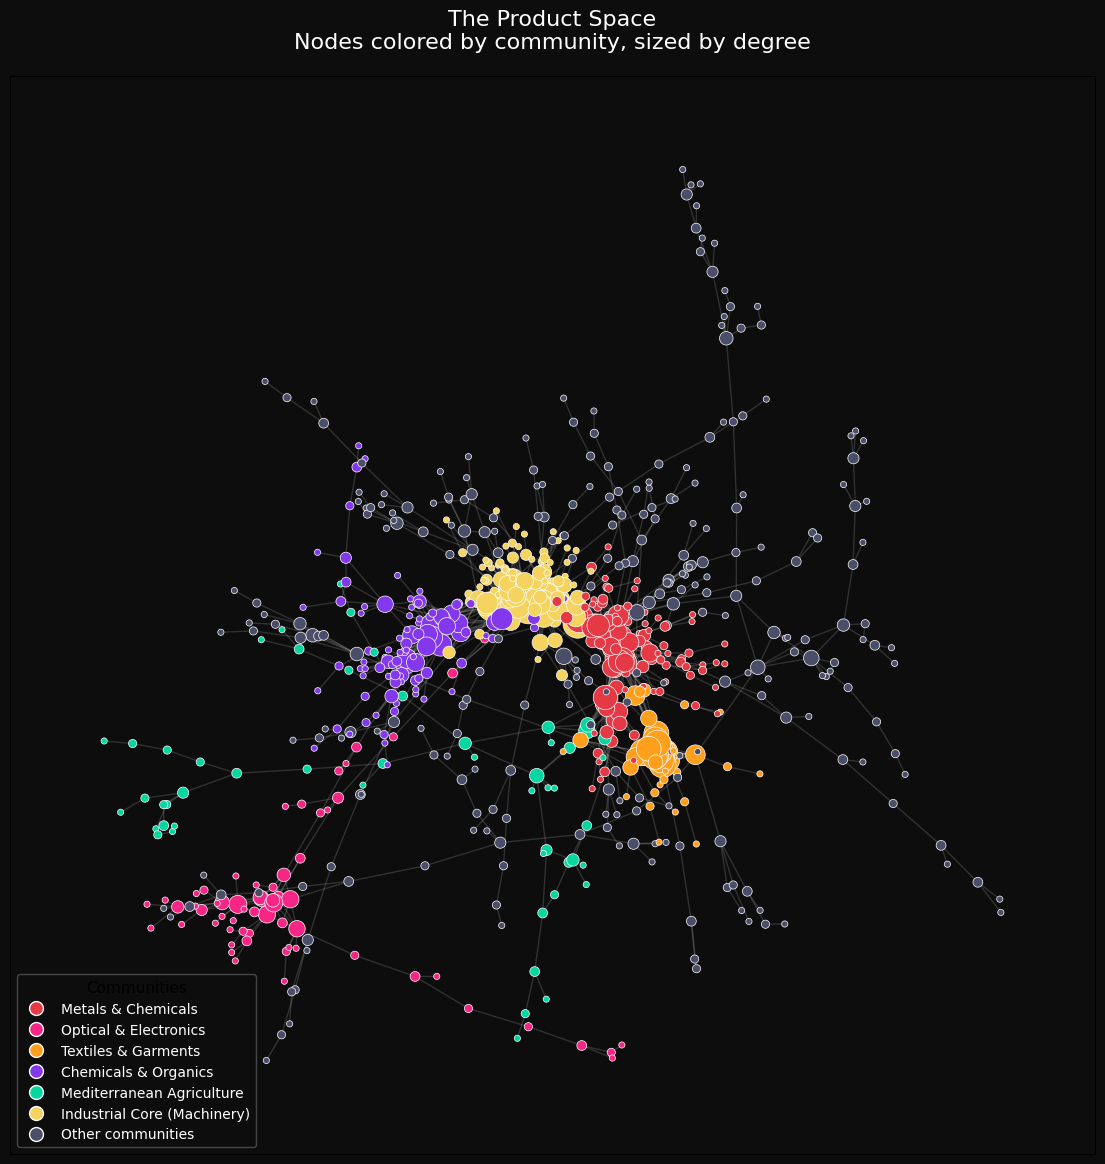

In [30]:
# Network visualization - nodes sized by degree, colored by community
from matplotlib.lines import Line2D

def draw_network(G, pos=None, node_colors="#5b8cc0", figsize=14):
    node_min_size = 5
    node_size_scaling = 15
    degree_sequence = dict(G.degree)

    if pos is None:
        pos = nx.spring_layout(G)

    node_sizes = [node_min_size + node_size_scaling * degree 
                  for node, degree in degree_sequence.items()]

    fig = plt.figure(figsize=(figsize, figsize), facecolor="#0d0d0d")
    ax = fig.add_subplot(111, facecolor="#0d0d0d")
    nx.draw_networkx_edges(G, pos, alpha=0.15, edge_color="white")
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors,
                           linewidths=0.5, edgecolors="white")
    plt.title("The Product Space\nNodes colored by community, sized by degree",
              fontsize=16, color="white", pad=20)
    return fig, ax

# Get largest connected component
largest_cc_nodes = max(nx.connected_components(G), key=len)
G_largest = G.subgraph(largest_cc_nodes).copy()

# Compute layout
pos = nx.spring_layout(G_largest, k=0.75, iterations=50, seed=42)

# Community map
community_map = nx.get_node_attributes(G_largest, "community")
all_communities = sorted(set(community_map.values()))

# One fully controlled color per community index
# Named 6 get vivid distinct colors, rest get muted grey/slate
named_colors = {
    0:  "#e63946",  # red           - Metals & Chemicals
    1:  "#f72585",  # hot pink      - Optical & Electronics
    2:  "#ff9f1c",  # orange        - Textiles & Garments
    4:  "#8338ec",  # purple        - Chemicals & Organics
    7:  "#06d6a0",  # green         - Mediterranean Agriculture
    20: "#f4d35e",  # yellow        - Industrial Core (Machinery)
}

community_labels = {
    0:  "Metals & Chemicals",
    1:  "Optical & Electronics",
    2:  "Textiles & Garments",
    4:  "Chemicals & Organics",
    7:  "Mediterranean Agriculture",
    20: "Industrial Core (Machinery)"
}

# All unnamed communities get a muted slate color
default_color = "#4a4e69"

node_colors = []
for node in G_largest.nodes():
    comm = community_map[node]
    node_colors.append(named_colors.get(comm, default_color))

# Build legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=named_colors[i],
           markersize=10, label=label, linestyle='None')
    for i, label in community_labels.items()
] + [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=default_color,
           markersize=10, label="Other communities", linestyle='None')
]

# Draw
fig, ax = draw_network(G=G_largest, pos=pos, node_colors=node_colors)
ax.legend(handles=legend_elements, loc="lower left", fontsize=10,
          framealpha=0.3, facecolor="#0d0d0d", labelcolor="white",
          title="Communities", title_fontsize=11)

plt.savefig("product_space_network.png", dpi=300, bbox_inches="tight",
            facecolor="#0d0d0d")
plt.show()

**Note on Visualization:**

The network is visualized using a force-directed spring layout, where nodes that 
share more connections are drawn closer together. Node size is proportional to 
degree: larger nodes are more connected products. The six largest communities 
are highlighted with distinct colors; all remaining communities appear in slate grey.

The visualization confirms the core-periphery structure identified throughout 
this analysis. The dense, highly connected industrial core (yellow, red, orange) 
sits at the centre, while peripheral communities such as Mediterranean Agriculture (teal) and Optical & Electronics (pink) form clearly separated clusters at the edges. The grey peripheral nodes, which are mostly isolated raw materials and niche products, are linked to the core by single connections, consistent with the high sparsity (0.9941) observed in Q1.

---

## 9. Conclusion

This analysis of the Product Space network (Hidalgo et al. (2007)) reveals a 
coherent and economically interpretable structure that goes well beyond what simple random models can explain.

The network is extremely sparse (0.9941), with a heavy-tailed degree distribution consistent with a power-law: a small number of industrial hub products concentrate most connections while the majority remain peripheral. 

The positive assortativity (0.46) confirms a rich-club effect: well-connected products cluster together, forming a dense industrial core surrounded by a sparse periphery.

Community detection via the Louvain algorithm identified 35 communities 
(modularity = 0.76) that map cleanly onto real industrial sectors: machinery, 
chemicals, textiles, and Mediterranean agriculture, validating the capability-based theory of economic complexity. 

Centrality analysis further revealed that degree and betweenness centrality identify fundamentally different types of important products: industrial hubs versus structural bridges linking otherwise disconnected sectors.

Finally, the configuration model test demonstrated that the high clustering 
coefficient (0.43) cannot be explained by the degree sequence alone (Z-score = 
142.61), confirming that the triangular structure of the Product Space reflects 
genuine underlying economic mechanisms rather than a statistical item of the network's connectivity pattern.

---
*Note: This analysis was conducted as part of the Social Network Analysis course 
at the Master in Computational Social Science, UC3M (2026). Code was written with the assistance of AI (Claude, Anthropic). All interpretations and discussions are my own.*

---

## References

Hidalgo, C.A., Klinger, B., Barabási, A.L., & Hausmann, R. (2007). The Product 
Space Conditions the Development of Nations. *Science*, 317(5837), 482–487. 
https://doi.org/10.1126/science.1144581

Hidalgo, C.A., & Hausmann, R. (2009). The Building Blocks of Economic Complexity. 
*PNAS*, 106(26), 10570–10575. 
https://doi.org/10.1073/pnas.0900943106

Coscia, M. (2012). The Product Space Dataset (SITC classification). 
Retrieved from https://www.michelecoscia.com/?page_id=223

Blondel, V.D., Guillaume, J.L., Lambiotte, R., & Lefebvre, E. (2008). 
Fast unfolding of communities in large networks. *Journal of Statistical 
Mechanics: Theory and Experiment*, 2008(10), P10008.
https://doi.org/10.1088/1742-5468/2008/10/P10008

Kolic, B. (2025). Social Network Analysis — UC3M Networks Workshop. 
Universidad Carlos III de Madrid. 
https://github.com/blas-ko/uc3m_networks_workshop_2025